Saved: results/figures/truncation_3d_demo.png


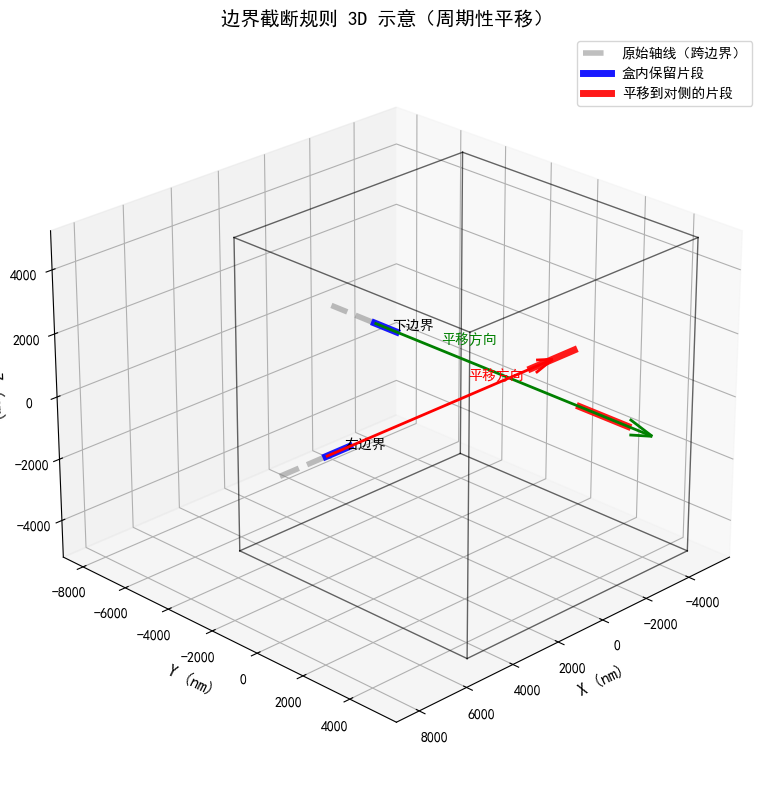

In [1]:
# === 边界截断规则 3D 可视化（双圆柱展示） ===
import matplotlib.pyplot as plt
# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

L = 10000.0
half = L / 2.0

# === 1. 绘制盒子边界 ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
for (i, j) in edges:
    ax.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
            color='black', linewidth=1.0, alpha=0.6)

# === 2. 圆柱1：跨右边界（X方向） ===
# 原始位置（灰色半透明）
p0_orig_1 = np.array([6000, 0, 0])
p1_orig_1 = np.array([8000, 0, 0])
ax.plot([p0_orig_1[0], p1_orig_1[0]], [p0_orig_1[1], p1_orig_1[1]], [p0_orig_1[2], p1_orig_1[2]],
        color='gray', linewidth=4, alpha=0.5, linestyle='--', label='原始轴线（跨边界）')

# 盒内部分（蓝色）
p0_inside_1 = np.array([5000, 0, 0])
p1_inside_1 = np.array([6000, 0, 0])
ax.plot([p0_inside_1[0], p1_inside_1[0]], [p0_inside_1[1], p1_inside_1[1]], [p0_inside_1[2], p1_inside_1[2]],
        color='blue', linewidth=5, alpha=0.9, label='盒内保留片段')

# 平移到对侧（红色）
p0_shifted_1 = np.array([-5000, 0, 0])
p1_shifted_1 = np.array([-3000, 0, 0])
ax.plot([p0_shifted_1[0], p1_shifted_1[0]], [p0_shifted_1[1], p1_shifted_1[1]], [p0_shifted_1[2], p1_shifted_1[2]],
        color='red', linewidth=5, alpha=0.9, label='平移到对侧的片段')

# 右边界标注
ax.text(half + 200, 0, 0, '右边界', color='black', fontsize=10)

# === 3. 圆柱2：跨下边界（Y方向） ===
# 原始位置（灰色半透明）
p0_orig_2 = np.array([-2000, -6000, 0])
p1_orig_2 = np.array([-2000, -8000, 0])
ax.plot([p0_orig_2[0], p1_orig_2[0]], [p0_orig_2[1], p1_orig_2[1]], [p0_orig_2[2], p1_orig_2[2]],
        color='gray', linewidth=4, alpha=0.5, linestyle='--')

# 盒内部分（蓝色）
p0_inside_2 = np.array([-2000, -5000, 0])
p1_inside_2 = np.array([-2000, -6000, 0])
ax.plot([p0_inside_2[0], p1_inside_2[0]], [p0_inside_2[1], p1_inside_2[1]], [p0_inside_2[2], p1_inside_2[2]],
        color='blue', linewidth=5, alpha=0.9)

# 平移到对侧（红色）
p0_shifted_2 = np.array([-2000, 5000, 0])
p1_shifted_2 = np.array([-2000, 3000, 0])
ax.plot([p0_shifted_2[0], p1_shifted_2[0]], [p0_shifted_2[1], p1_shifted_2[1]], [p0_shifted_2[2], p1_shifted_2[2]],
        color='red', linewidth=5, alpha=0.9)

# 下边界标注
ax.text(-2000, -half - 200, 0, '下边界', color='black', fontsize=10)

# === 4. 平移方向箭头 ===
# 箭头1：从右边界指向左边界
ax.quiver(6000, 0, 0, -10000, 0, 0, color='red', linewidth=2, arrow_length_ratio=0.08)
ax.text(-1000, -800, 0, '平移方向', color='red', fontsize=10)

# 箭头2：从下边界指向上边界
ax.quiver(-2000, -6000, 0, 0, 12000, 0, color='green', linewidth=2, arrow_length_ratio=0.08)
ax.text(-2000, -3000, 200, '平移方向', color='green', fontsize=10)

# === 5. 图例 ===
ax.legend(loc='upper right', fontsize=10)

# === 6. 坐标轴 ===
ax.set_xlabel('X (nm)', fontsize=12)
ax.set_ylabel('Y (nm)', fontsize=12)
ax.set_zlabel('Z (nm)', fontsize=12)
ax.set_title('边界截断规则 3D 示意（周期性平移）', fontsize=14)

# === 7. 视角 ===
ax.view_init(elev=25, azim=45)

plt.tight_layout()
out_path = 'results/figures/truncation_3d_demo.png'
plt.savefig(out_path, dpi=300)
print(f"Saved: {out_path}")
plt.show()

Saved: results/figures/truncation_3frame_process.png


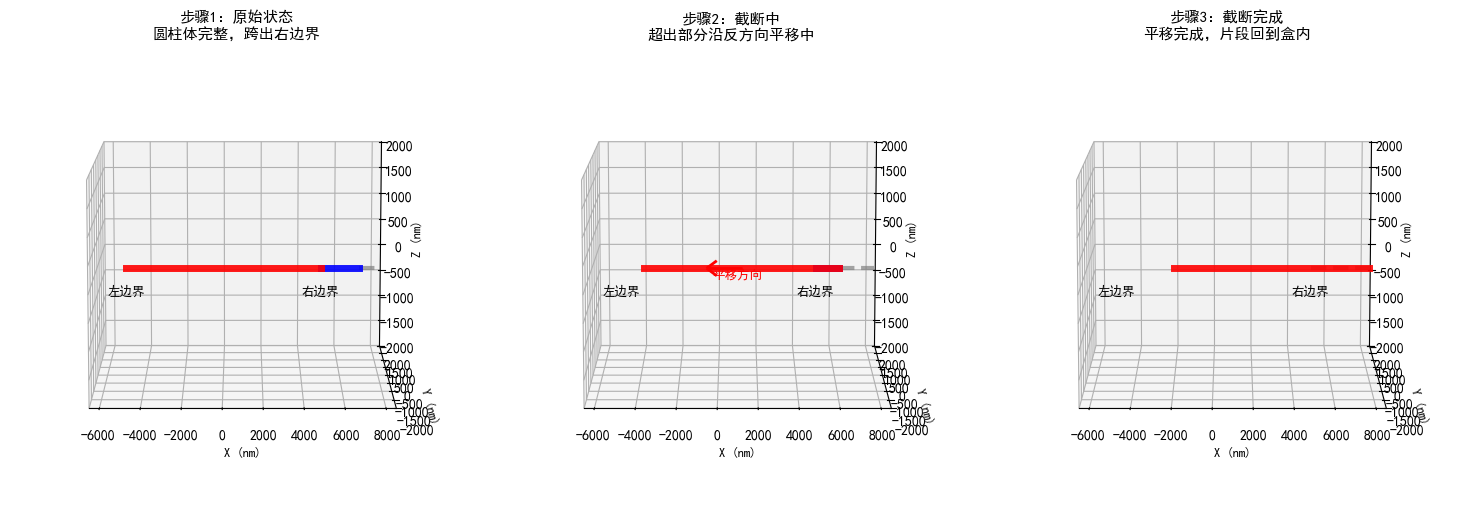

In [2]:
# === 边界截断三帧过程图（展示动态平移） ===
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

L = 10000.0
half = L / 2.0

# 定义三个状态
stages = [
    {"title": "步骤1：原始状态", "offset": 0, "desc": "圆柱体完整，跨出右边界"},
    {"title": "步骤2：截断中", "offset": 0.4, "desc": "超出部分沿反方向平移中"},
    {"title": "步骤3：截断完成", "offset": 1.0, "desc": "平移完成，片段回到盒内"}
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})

for idx, (ax, stage) in enumerate(zip(axes, stages)):
    offset = stage["offset"]
    
    # 原始位置：x=5000 到 x=8000（跨边界）
    p0_orig = np.array([5000 + 2000*(1-offset), 0, 0])
    p1_orig = np.array([8000, 0, 0])
    
    # 盒内部分：x=5000 到 p0_orig
    p0_inside = np.array([5000, 0, 0])
    p1_inside = np.array([p0_orig[0], 0, 0])
    
    # 平移部分：从右侧平移到左侧
    # 起始位置在右侧 x=5000+offset*3000，终点在左侧 x=-5000+offset*3000
    shift_start = 5000 + offset * 3000
    shift_end = -5000 + offset * 3000
    p0_shift = np.array([shift_start, 0, 0])
    p1_shift = np.array([shift_end, 0, 0])
    
    # 盒子边界
    ax.axvline(-half, 0, 0, color='black', linewidth=2)
    ax.axvline(half, 0, 0, color='black', linewidth=2)
    
    # 绘制原始轴线（灰色虚线）
    ax.plot([p0_orig[0], p1_orig[0]], [0, 0], [0, 0],
            color='gray', linewidth=3, linestyle='--', alpha=0.7)
    
    # 绘制盒内片段（蓝色）
    ax.plot([p0_inside[0], p1_inside[0]], [0, 0], [0, 0],
            color='blue', linewidth=5, alpha=0.9)
    
    # 绘制平移到对侧的片段（红色）
    ax.plot([p0_shift[0], p1_shift[0]], [0, 0], [0, 0],
            color='red', linewidth=5, alpha=0.9)
    
    # 标注边界
    ax.text(-half, 0, -500, '左边界', fontsize=9, ha='center')
    ax.text(half, 0, -500, '右边界', fontsize=9, ha='center')
    
    # 箭头（步骤2显示平移方向）
    if offset > 0.1 and offset < 0.9:
        mid_x = (p0_shift[0] + p1_shift[0]) / 2
        ax.quiver(mid_x, 0, 0, -3000*(1-offset), 0, 0, color='red', linewidth=2)
        ax.text(mid_x - 1500, -800, 0, '平移方向', color='red', fontsize=9)
    
    # 标题
    ax.set_title(f"{stage['title']}\n{stage['desc']}", fontsize=11)
    ax.set_xlim(-6500, 8500)
    ax.set_ylim(-2000, 2000)
    ax.set_zlim(-2000, 2000)
    ax.set_xlabel('X (nm)', fontsize=9)
    ax.set_ylabel('Y (nm)', fontsize=9)
    ax.set_zlabel('Z (nm)', fontsize=9)
    ax.view_init(elev=10, azim=-90)  # 俯视图视角

plt.tight_layout()
out_path = 'results/figures/truncation_3frame_process.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

Saved: results/figures/truncation_3d_simulation.png


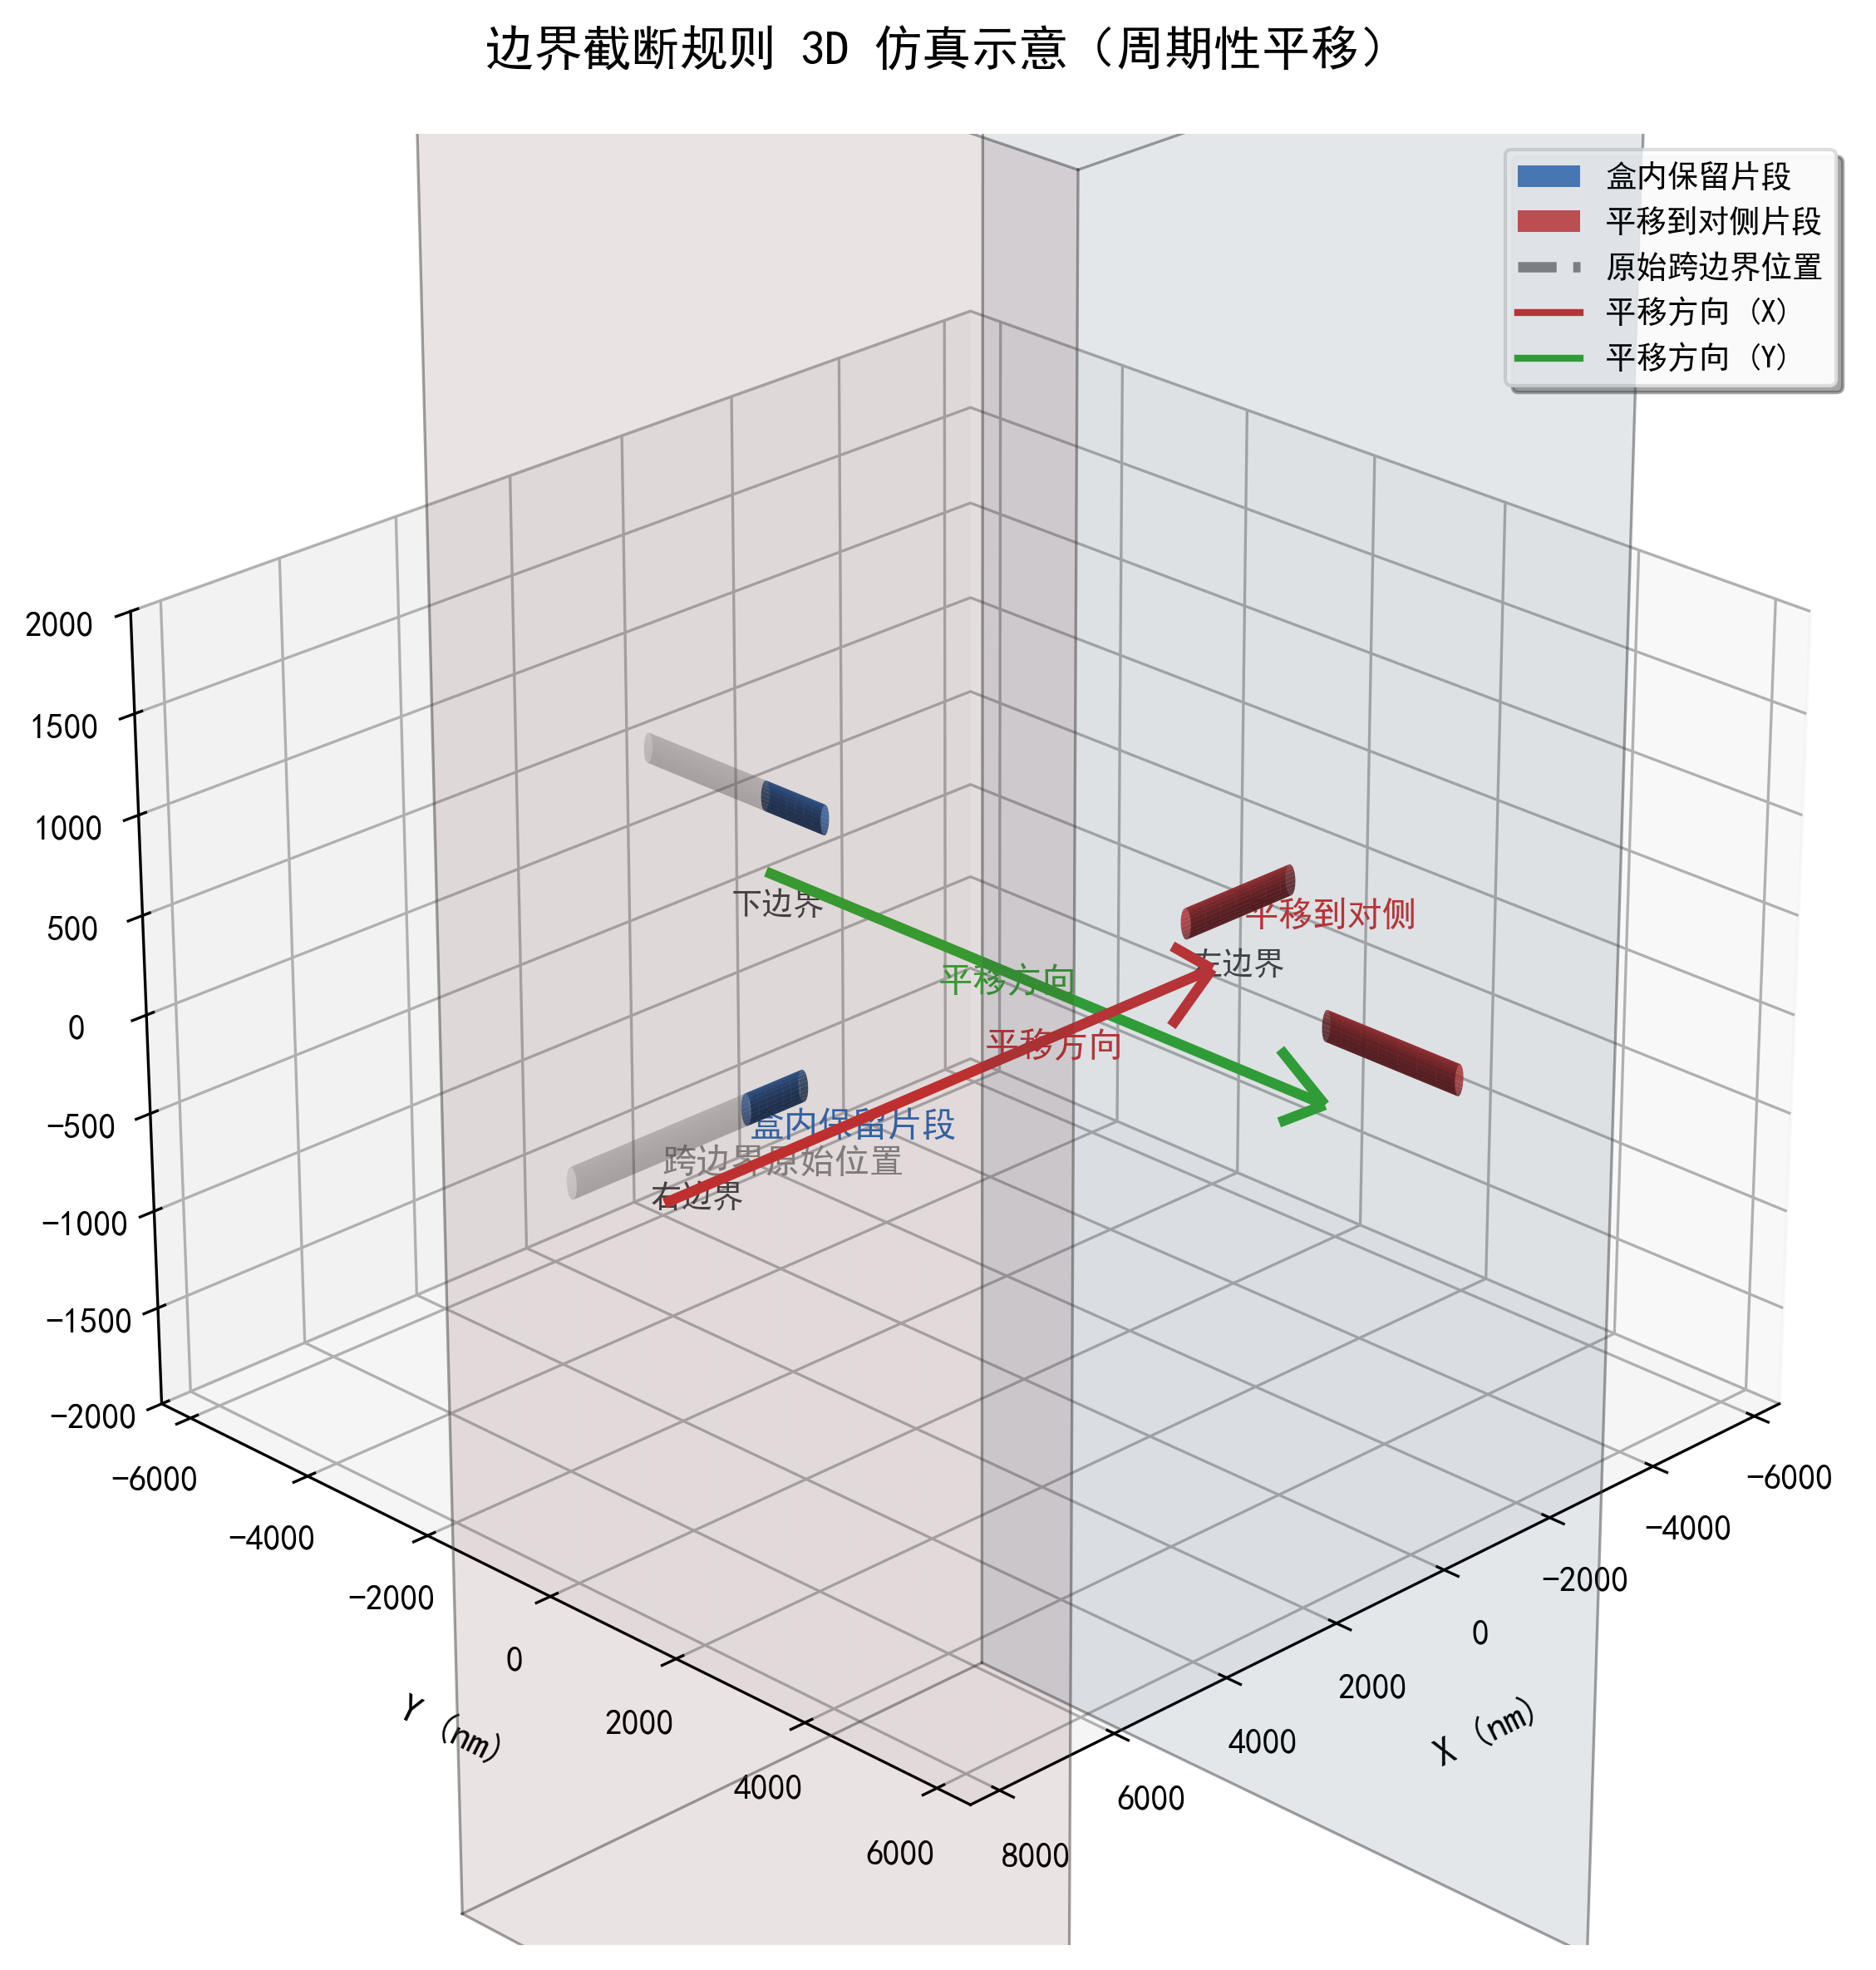

In [ ]:
# === 仿真图 ===
import matplotlib.pyplot as plt
# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# 设置高分辨率 + 干净背景
plt.rcParams['figure.dpi'] = 300

plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

L = 10000.0
half = L / 2.0

# === 1. 绘制盒子边界（细线，不抢眼） ===
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
for (i, j) in edges:
    ax.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
            color='#444444', linewidth=0.8, alpha=0.5)

# === 2. 绘制电极平面（半透明带网格） ===
yy, zz = np.meshgrid(np.linspace(-half, half, 10), np.linspace(-half, half, 10))

# 左电极
ax.plot_surface(-half * np.ones_like(yy), yy, zz, 
                color='#4A90D9', alpha=0.12, edgecolor='none')
# 右电极
ax.plot_surface(half * np.ones_like(yy), yy, zz, 
                color='#D94A4A', alpha=0.12, edgecolor='none')

# === 3. 圆柱体1：跨右边界（完整仿真级渲染） ===
# 使用圆柱面网格 + 光照
def create_cylinder_surface(p0, p1, radius, n_theta=24, n_z=8, color='blue', alpha=0.85):
    p0 = np.array(p0)
    p1 = np.array(p1)
    v = p1 - p0
    length = np.linalg.norm(v)
    if length < 1e-12:
        return None
    w = v / length
    arbitrary = np.array([1.0, 0.0, 0.0]) if abs(w[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(w, arbitrary)
    u = u / np.linalg.norm(u)
    v_perp = np.cross(w, u)
    
    theta = np.linspace(0, 2*np.pi, n_theta)
    z = np.linspace(0, length, n_z)
    theta_grid, z_grid = np.meshgrid(theta, z)
    X = np.zeros_like(theta_grid)
    Y = np.zeros_like(theta_grid)
    Z = np.zeros_like(theta_grid)
    for i in range(n_z):
        for j in range(n_theta):
            pt = p0 + w * z_grid[i,j] + radius * (np.cos(theta_grid[i,j]) * u + np.sin(theta_grid[i,j]) * v_perp)
            X[i,j], Y[i,j], Z[i,j] = pt
    return X, Y, Z

# 跨边界圆柱（灰色半透明，原始位置）
cyl1_orig = create_cylinder_surface([5000, 0, 0], [8000, 0, 0], 80, color='gray', alpha=0.25)
if cyl1_orig:
    ax.plot_surface(cyl1_orig[0], cyl1_orig[1], cyl1_orig[2], 
                    color='#888888', alpha=0.2, edgecolor='none')

# 盒内部分（蓝色，高光）
cyl1_inside = create_cylinder_surface([4000, 0, 0], [5000, 0, 0], 80, color='blue', alpha=0.85)
if cyl1_inside:
    ax.plot_surface(cyl1_inside[0], cyl1_inside[1], cyl1_inside[2], 
                    color='#2E6BB5', alpha=0.85, edgecolor='none', 
                    rstride=1, cstride=1)

# 平移到对侧（红色，高光）
cyl1_shifted = create_cylinder_surface([-5000, 0, 0], [-3000, 0, 0], 80, color='red', alpha=0.85)
if cyl1_shifted:
    ax.plot_surface(cyl1_shifted[0], cyl1_shifted[1], cyl1_shifted[2], 
                    color='#CC3333', alpha=0.85, edgecolor='none',
                    rstride=1, cstride=1)

# === 4. 圆柱体2：跨Y边界（展示多方向） ===
cyl2_orig = create_cylinder_surface([-2000, -6000, 0], [-2000, -8000, 0], 80, color='gray', alpha=0.2)
if cyl2_orig:
    ax.plot_surface(cyl2_orig[0], cyl2_orig[1], cyl2_orig[2], 
                    color='#888888', alpha=0.2, edgecolor='none')

cyl2_inside = create_cylinder_surface([-2000, -5000, 0], [-2000, -6000, 0], 80, color='blue', alpha=0.85)
if cyl2_inside:
    ax.plot_surface(cyl2_inside[0], cyl2_inside[1], cyl2_inside[2], 
                    color='#2E6BB5', alpha=0.85, edgecolor='none')

cyl2_shifted = create_cylinder_surface([-2000, 5000, 0], [-2000, 3000, 0], 80, color='red', alpha=0.85)
if cyl2_shifted:
    ax.plot_surface(cyl2_shifted[0], cyl2_shifted[1], cyl2_shifted[2], 
                    color='#CC3333', alpha=0.85, edgecolor='none')

# === 5. 平移方向箭头（带阴影效果） ===
def arrow3d(ax, start, end, color='red', lw=2.5):
    ax.quiver(start[0], start[1], start[2], 
              end[0]-start[0], end[1]-start[1], end[2]-start[2],
              color=color, linewidth=lw, arrow_length_ratio=0.08)

# 箭头1：X方向
arrow3d(ax, [6000, -400, -400], [-4000, -400, -400], color='#CC3333', lw=3)
ax.text(-1000, -400, -500, '平移方向', color='#CC3333', fontsize=10, fontweight='bold', ha='center')

# 箭头2：Y方向
arrow3d(ax, [-2000, -6000, -400], [-2000, 3000, -400], color='#33AA33', lw=3)
ax.text(-2000, -2000, -500, '平移方向', color='#33AA33', fontsize=10, fontweight='bold', ha='center')

# === 6. 标注文字（带引线/背景） ===
ax.text(5500, 500, 0, '盒内保留片段', color='#2E6BB5', fontsize=10, fontweight='bold')
ax.text(-3500, 500, 0, '平移到对侧', color='#CC3333', fontsize=10, fontweight='bold')
ax.text(7000, 500, 0, '跨边界原始位置', color='#888888', fontsize=10, fontweight='bold')

# 边界标注
ax.text(-half, -800, -600, '左边界', color='#444444', fontsize=9, ha='center')
ax.text(half, -800, -600, '右边界', color='#444444', fontsize=9, ha='center')
ax.text(-2000, -half-800, -600, '下边界', color='#444444', fontsize=9, ha='center')

# === 7. 图例（自定义） ===
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#2E6BB5', alpha=0.85, label='盒内保留片段'),
    Patch(facecolor='#CC3333', alpha=0.85, label='平移到对侧片段'),
    Line2D([0], [0], color='#888888', linewidth=3, linestyle='--', label='原始跨边界位置'),
    Line2D([0], [0], color='#CC3333', linewidth=2, label='平移方向 (X)'),
    Line2D([0], [0], color='#33AA33', linewidth=2, label='平移方向 (Y)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, 
          edgecolor='#dddddd', shadow=True)

# === 8. 坐标轴与视角 ===
ax.set_xlabel('X (nm)', fontsize=11, labelpad=10)
ax.set_ylabel('Y (nm)', fontsize=11, labelpad=10)
ax.set_zlabel('Z (nm)', fontsize=11, labelpad=10)
ax.set_title('边界截断规则 3D 仿真示意（周期性平移）', fontsize=14, fontweight='bold', pad=20)

# 等轴距 + 最佳视角
ax.view_init(elev=25, azim=45)
ax.set_xlim(-6500, 8500)
ax.set_ylim(-6500, 6500)
ax.set_zlim(-2000, 2000)

plt.tight_layout()
out_path = 'results/figures/truncation_3d_simulation.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()

Saved: results/figures/truncation_before_after.png


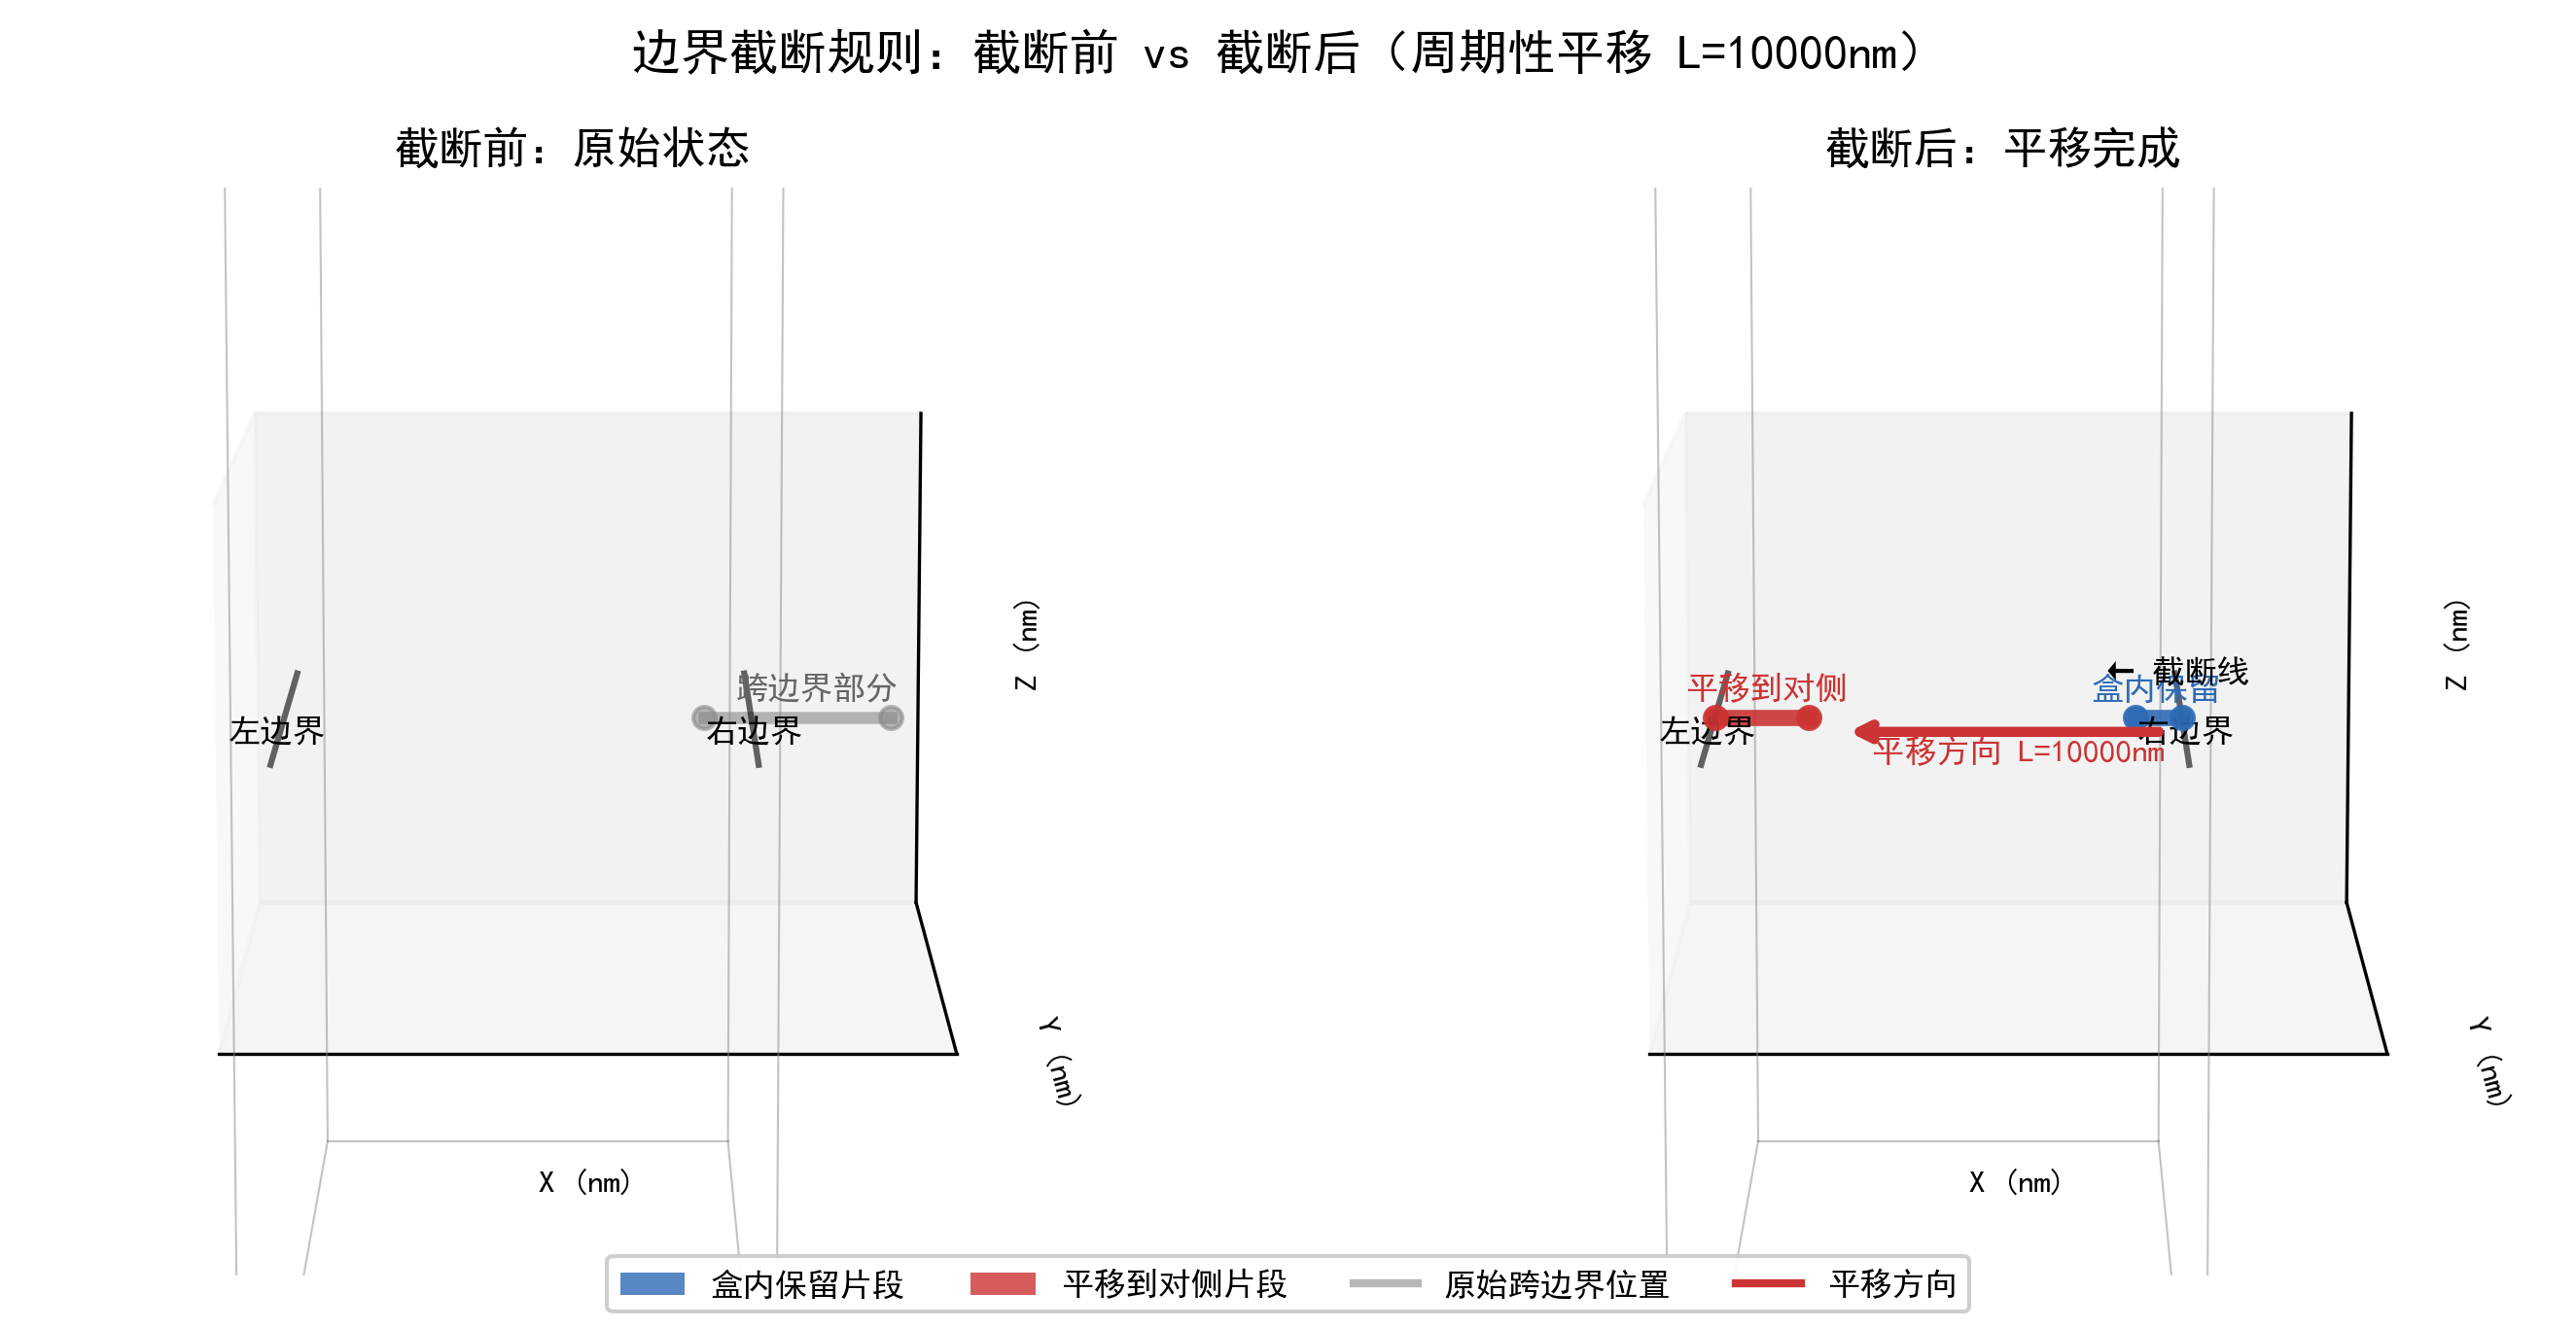

In [4]:
# === 边界截断规则：截断前 vs 截断后 并排对比（工科论文级） ===
import matplotlib.pyplot as plt
# 1. 设置支持中文的字体（Windows 常用的是黑体 SimHei 或者微软雅黑 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False  
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 设置字体

plt.rcParams['font.size'] = 9

# 创建 1行2列 子图（并排对比）
fig = plt.figure(figsize=(10, 4.5))
fig.suptitle('边界截断规则：截断前 vs 截断后（周期性平移 L=10000nm）', fontsize=12, fontweight='bold')

L = 10000.0
half = L / 2.0

# === 子图1：截断前（原始状态） ===
ax1 = fig.add_subplot(121, projection='3d')

# 盒子边界（细线）
corners = np.array([
    [-half, -half, -half], [half, -half, -half],
    [half, half, -half], [-half, half, -half],
    [-half, -half, half], [half, -half, half],
    [half, half, half], [-half, half, half]
])
edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]
for (i, j) in edges:
    ax1.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
             color='#888888', linewidth=0.5, alpha=0.5)

# 绘制圆柱函数（用线段表示）
def draw_cylinder(ax, p0, p1, radius, color, alpha=0.7, linewidth=2):
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], 
            color=color, linewidth=linewidth, alpha=alpha, linestyle='-' if alpha>0.5 else '--')
    for pt in [p0, p1]:
        ax.scatter(pt[0], pt[1], pt[2], color=color, s=30, alpha=alpha)

# 跨边界圆柱（灰色，从x=4000到x=8000）
draw_cylinder(ax1, [4000, 0, 0], [8000, 0, 0], 30, '#888888', alpha=0.6, linewidth=3)

# 标注边界
ax1.plot([-half, -half], [-1500, 1500], [0, 0], color='black', linewidth=1.5, alpha=0.6)
ax1.plot([half, half], [-1500, 1500], [0, 0], color='black', linewidth=1.5, alpha=0.6)

ax1.text(-half, -800, 0, '左边界', fontsize=8, ha='center', color='black')
ax1.text(half, -800, 0, '右边界', fontsize=8, ha='center', color='black')
ax1.text(6500, 600, 0, '跨边界部分', fontsize=8, color='#666666', ha='center')

ax1.set_title('截断前：原始状态', fontsize=11, fontweight='bold')
ax1.set_xlim(-6000, 9000)
ax1.set_ylim(-2000, 2000)
ax1.set_zlim(-2000, 2000)
ax1.set_xlabel('X (nm)', fontsize=8)
ax1.set_ylabel('Y (nm)', fontsize=8)
ax1.set_zlabel('Z (nm)', fontsize=8)
ax1.view_init(elev=10, azim=-90)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])

# === 子图2：截断后（平移完成） ===
ax2 = fig.add_subplot(122, projection='3d')

# 盒子边界
for (i, j) in edges:
    ax2.plot([corners[i,0], corners[j,0]], [corners[i,1], corners[j,1]], [corners[i,2], corners[j,2]],
             color='#888888', linewidth=0.5, alpha=0.5)

# 盒内部分（蓝色，从x=4000到x=5000）
draw_cylinder(ax2, [4000, 0, 0], [5000, 0, 0], 30, '#2E6BB5', alpha=0.9, linewidth=4)
ax2.text(4500, 600, 0, '盒内保留', fontsize=8, color='#2E6BB5', ha='center', fontweight='bold')

# 平移到对侧（红色，从x=-5000到x=-3000）
draw_cylinder(ax2, [-5000, 0, 0], [-3000, 0, 0], 30, '#CC3333', alpha=0.9, linewidth=4)
ax2.text(-4000, 600, 0, '平移到对侧', fontsize=8, color='#CC3333', ha='center', fontweight='bold')

# 边界标注
ax2.plot([-half, -half], [-1500, 1500], [0, 0], color='black', linewidth=1.5, alpha=0.6)
ax2.plot([half, half], [-1500, 1500], [0, 0], color='black', linewidth=1.5, alpha=0.6)

ax2.text(-half, -800, 0, '左边界', fontsize=8, ha='center', color='black')
ax2.text(half, -800, 0, '右边界', fontsize=8, ha='center', color='black')

# === 关键修复：平移方向箭头（用 annotate 的 2D 坐标） ===
# 在 3D 子图中，annotate 的 xy 和 xytext 必须是 2D 坐标
# 但我们可以在 2D 坐标上画箭头，然后通过 transform 映射
ax2.annotate('', xy=(0.35, 0.5), xytext=(0.65, 0.5),
             xycoords='axes fraction', textcoords='axes fraction',
             arrowprops=dict(arrowstyle='->', color='#CC3333', lw=2.5))

# 用 text 在 3D 坐标中标注平移方向
ax2.text(1500, -1400, 0, '平移方向 L=10000nm', fontsize=8, color='#CC3333', ha='center', fontweight='bold')

# 标注“截断线”
ax2.text(5000, 1200, 0, '← 截断线', fontsize=8, color='black', ha='center')

ax2.set_title('截断后：平移完成', fontsize=11, fontweight='bold')
ax2.set_xlim(-6000, 9000)
ax2.set_ylim(-2000, 2000)
ax2.set_zlim(-2000, 2000)
ax2.set_xlabel('X (nm)', fontsize=8)
ax2.set_ylabel('Y (nm)', fontsize=8)
ax2.set_zlabel('Z (nm)', fontsize=8)
ax2.view_init(elev=10, azim=-90)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_zticks([])

# === 图例（统一放在底部） ===
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#2E6BB5', alpha=0.8, label='盒内保留片段'),
    Patch(facecolor='#CC3333', alpha=0.8, label='平移到对侧片段'),
    Line2D([0], [0], color='#888888', linewidth=2, linestyle='-', alpha=0.6, label='原始跨边界位置'),
    Line2D([0], [0], color='#CC3333', linewidth=2, label='平移方向'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=8, framealpha=0.95)

plt.tight_layout()
out_path = 'results/figures/truncation_before_after.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f"Saved: {out_path}")
plt.show()